Mounted at /content/drive
Top Features: ['dttl', 'sttl', 'sbytes', 'service', 'ct_srv_dst', 'swin', 'ct_dst_src_ltm', 'ct_dst_sport_ltm', 'tcprtt', 'dmean', 'dbytes', 'proto', 'smean', 'synack', 'ct_src_dport_ltm', 'ct_state_ttl', 'ct_srv_src']

Training BiLSTM NU = 32
Epoch 1/40
242/242 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6978 - loss: 0.9514 - val_accuracy: 0.4497 - val_loss: 1.5929
Epoch 2/40
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7753 - loss: 0.6265 - val_accuracy: 0.6497 - val_loss: 0.9684
Epoch 3/40
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8067 - loss: 0.5436 - val_accuracy: 0.8182 - val_loss: 0.5077
Epoch 4/40
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8208 - loss: 0.5011 - val_accuracy: 0.8317 - val_loss: 0.4604
Epoch 5/40
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8248 - loss: 0.4820 - val_accuracy: 0.8366 - val_loss: 0.4423
Epoch 6/40
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8315 - loss: 0.46

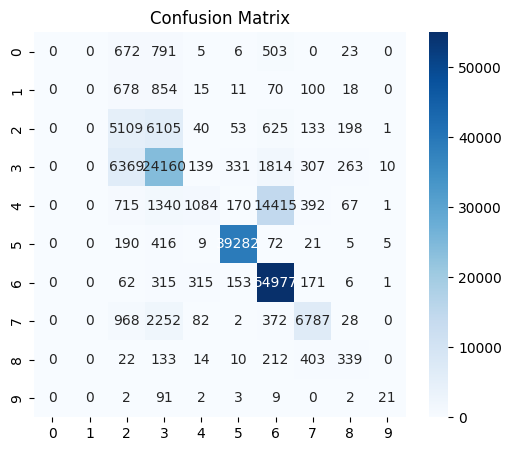

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━

/tmp/ipykernel_25492/1315718340.py:249: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_flat[:50], feature_names=top_features)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-pack

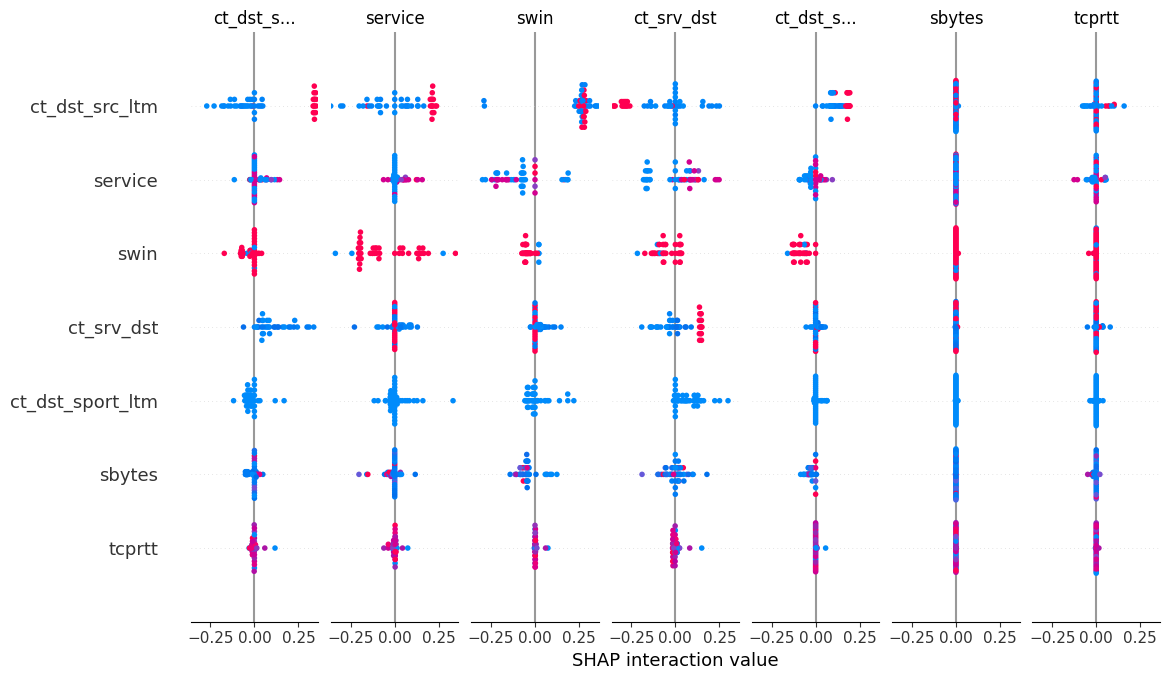

In [1]:
# =========================================================
# BiLSTM + Attention + XGBoost + SHAP (FULL FINAL CODE)
# =========================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import tensorflow as tf
import random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer

# =========================================================
# SEED
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# =========================================================
# LOAD DATA
# =========================================================
base_path = "/content/drive/MyDrive/UNSW_NB15/"

train_df = pd.read_csv(base_path + "UNSW_NB15_training-set.csv")
test_df  = pd.read_csv(base_path + "UNSW_NB15_testing-set.csv")

train_df.drop(columns=["id"], inplace=True)
test_df.drop(columns=["id"], inplace=True)

train_df["label"] = train_df["attack_cat"]
test_df["label"]  = test_df["attack_cat"]

train_df.drop(columns=["attack_cat"], inplace=True)
test_df.drop(columns=["attack_cat"], inplace=True)

train_df = train_df.dropna(subset=["label"])
test_df  = test_df.dropna(subset=["label"])

# =========================================================
# ENCODING
# =========================================================
cat_cols = ["proto","service","state"]

for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col]]))
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# =========================================================
# SPLIT
# =========================================================
train_df, val_df = train_test_split(
    train_df, test_size=0.25,
    stratify=train_df["label"],
    random_state=42
)

# =========================================================
# XGBOOST FEATURE SELECTION
# =========================================================
X_fs = train_df.drop("label", axis=1)
y_fs = train_df["label"]

le_fs = LabelEncoder()
y_fs_enc = le_fs.fit_transform(y_fs)

xgb = XGBClassifier(n_estimators=150, max_depth=6,
                    learning_rate=0.1, eval_metric="mlogloss")

xgb.fit(X_fs, y_fs_enc)

feat_df = pd.DataFrame({
    "Feature": X_fs.columns,
    "FI": xgb.feature_importances_
}).sort_values("FI", ascending=False)

top_features = list(feat_df.head(17)["Feature"])
print("Top Features:", top_features)

# =========================================================
# DATA PREP
# =========================================================
X_train = train_df[top_features]
X_val   = val_df[top_features]
X_test  = test_df[top_features]

y_train = train_df["label"]
y_val   = val_df["label"]
y_test  = test_df["label"]

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)

y_train = to_categorical(y_train_enc, num_classes)
y_val   = to_categorical(y_val_enc, num_classes)
y_test  = to_categorical(y_test_enc, num_classes)

# =========================================================
# SCALING
# =========================================================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train = X_train.reshape(-1,1,len(top_features))
X_val   = X_val.reshape(-1,1,len(top_features))
X_test  = X_test.reshape(-1,1,len(top_features))

# =========================================================
# ATTENTION LAYER
# =========================================================
class AttentionLayer(Layer):
    def build(self,input_shape):
        self.W=self.add_weight(shape=(input_shape[-1],1),initializer="normal")
        self.b=self.add_weight(shape=(input_shape[1],1),initializer="zeros")
        super().build(input_shape)

    def call(self,x):
        e=K.tanh(K.dot(x,self.W)+self.b)
        a=K.softmax(e,axis=1)
        return K.sum(x*a,axis=1)

# =========================================================
# BiLSTM MODEL (NOVELTY)
# =========================================================
def build_bilstm(nu):

    inputs = Input(shape=(1,len(top_features)))

    x = Bidirectional(LSTM(nu, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(nu, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(nu, return_sequences=True))(x)

    x = AttentionLayer()(x)

    x = Dense(nu//2, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================================================
# TRAIN MULTIPLE MODELS
# =========================================================
NU_list = [32, 64, 128]
results = []

for nu in NU_list:

    print(f"\nTraining BiLSTM NU = {nu}")

    model = build_bilstm(nu)

    start = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=40,
        batch_size=256,
        validation_data=(X_val, y_val),
        verbose=1
    )

    training_time = time.time() - start

    # VAC
    val_preds = np.argmax(model.predict(X_val), axis=1)
    VAC = accuracy_score(y_val_enc, val_preds)

    # TAC
    test_preds = np.argmax(model.predict(X_test), axis=1)
    TAC = accuracy_score(y_test_enc, test_preds)

    # F1
    F1 = f1_score(y_test_enc, test_preds, average="weighted")

    results.append([nu, VAC, TAC, F1, training_time])

# =========================================================
# RESULTS TABLE
# =========================================================
results_df = pd.DataFrame(
    results,
    columns=["NU","VAC","TAC","F1","Training Time"]
)

results_df = results_df.sort_values(by="TAC", ascending=False)

print("\nFinal Results:\n")
print(results_df)

# =========================================================
# CONFUSION MATRIX (LAST MODEL)
# =========================================================
cm = confusion_matrix(y_test_enc, test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# SHAP
# =========================================================
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[2])
X_test_flat  = X_test.reshape(X_test.shape[0], X_test.shape[2])

def predict_flat(x):
    x = x.reshape(x.shape[0], 1, x.shape[1])
    return model.predict(x)

explainer = shap.KernelExplainer(predict_flat, X_train_flat[:100])
shap_values = explainer.shap_values(X_test_flat[:50])

shap.summary_plot(shap_values, X_test_flat[:50], feature_names=top_features)